Data Setup

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_sub = pd.read_csv("sample_submission.csv")

In [37]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (2307, 7)
Test shape: (578, 2)


,M-ID,SMILE,P1,P2,P3,P4,P5
0,M360240,O=C(O)[C@H]1O[C@H]1C(=O)O,0,0,0,0,0
1,M865610,Cc1ccccc1-c1nccc(-n2ccnc2)n1,1,1,0,1,1
2,M271793,Cc1ccc(S(=O)(=O)NC(=O)Nc2ncn[nH]2)cc1,0,0,0,0,0
3,M689037,CC1(C)O[C@H]2O[C@@H]([C@H](O)CON3C(=O)c4ccccc4...,0,0,0,0,0
4,M486282,Cc1ccnc2nc(C(=O)OCC(=O)Nc3ccc4c(c3)OC(F)(F)O4)...,1,0,0,0,0


In [38]:
print(train.columns)

Index(['M-ID', 'SMILE', 'P1', 'P2', 'P3', 'P4', 'P5'], dtype='object')


In [39]:
target_cols = ['P1', 'P2', 'P3', 'P4', 'P5']

In [40]:
print("train_null :",train.isnull().sum().sum())
print("test_null :",test.isnull().sum().sum())

train_null : 0
test_null : 0


In [41]:
print("train_duplicated :",train.duplicated().sum())
print("test_duplicated :",test.duplicated().sum())

train_duplicated : 0
test_duplicated : 0


In [42]:
for col in target_cols:
  print(col, train[col].value_counts(normalize=True))

# Imbalanced Data, especially P4

P1 P1
0    0.759428
1    0.240572
Name: proportion, dtype: float64
P2 P2
0    0.751625
1    0.248375
Name: proportion, dtype: float64
P3 P3
0    0.810143
1    0.189857
Name: proportion, dtype: float64
P4 P4
0    0.880364
1    0.119636
Name: proportion, dtype: float64
P5 P5
0    0.781101
1    0.218899
Name: proportion, dtype: float64


In [43]:
!pip install rdkit

In [44]:
from rdkit import Chem

def is_valid_smiles(smiles):
    return Chem.MolFromSmiles(smiles) is not None

train["valid"] = train["SMILE"].apply(is_valid_smiles)

print("Invalid SMILES:", (~train["valid"]).sum())

Invalid SMILES: 0


SMILES - Graph Conversion

In [45]:
!pip install torch torchvision torchaudio
!pip install torch-geometric

In [46]:
from rdkit import Chem
import torch
from torch_geometric.data import Data

In [47]:
def get_atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalValence(),
        int(atom.GetIsAromatic()),
        int(atom.GetHybridization()),
    ]

In [48]:
def mol_to_graph(smiles, y=None):
    mol = Chem.MolFromSmiles(smiles)

    # Node features
    x = []
    for atom in mol.GetAtoms():
        x.append(get_atom_features(atom))
    x = torch.tensor(x, dtype=torch.float)

    # Edge index
    edge_index = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])  # undirected graph

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    # Labels
    if y is not None:
        y = torch.tensor(np.array(y, dtype=float), dtype=torch.float).unsqueeze(0)
    return Data(x=x, edge_index=edge_index, y=y)

In [49]:
train_graphs = []

for _, row in train.iterrows():

    labels = row[target_cols].to_numpy(dtype=float)

    labels = labels.reshape(1, 5)

    g = mol_to_graph(row["SMILE"], labels)

    if g is not None:
        train_graphs.append(g)

In [50]:
sample = train.iloc[0]

graph = mol_to_graph(sample["SMILE"], sample[["P1","P2","P3","P4","P5"]].values)

print(graph)

Data(x=[9, 6], edge_index=[2, 18], y=[1, 5])


In [51]:
from tqdm import tqdm

target_cols = ["P1","P2","P3","P4","P5"]

train_graphs = []

for _, row in tqdm(train.iterrows(), total=len(train)):
    g = mol_to_graph(row["SMILE"], row[target_cols].values)
    train_graphs.append(g)

100%|██████████| 2307/2307 [00:04<00:00, 543.50it/s]


In [52]:
test_graphs = []

for _, row in tqdm(test.iterrows(), total=len(test)):
    g = mol_to_graph(row["SMILE"])
    test_graphs.append(g)

100%|██████████| 578/578 [00:01<00:00, 401.64it/s]


In [53]:
print(train_graphs[0])

Data(x=[9, 6], edge_index=[2, 18], y=[1, 5])


In [54]:
print(train_graphs[0].x.shape)

torch.Size([9, 6])


Data Split And DataLoader

In [55]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_graphs, test_size=0.2, random_state=42
)

In [56]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

In [57]:
batch = next(iter(train_loader))

print(batch)

DataBatch(x=[777, 6], edge_index=[2, 1668], y=[32, 5], batch=[777], ptr=[33])


In [58]:
print("Node features shape:", batch.x.shape)
print("Batch vector:", batch.batch[:20])

Node features shape: torch.Size([777, 6])
Batch vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [59]:
for batch in train_loader:
    print(batch.x.shape)
    print(batch.edge_index.shape)
    print(batch.y.shape)
    break

torch.Size([882, 6])
torch.Size([2, 1900])
torch.Size([32, 5])


In [60]:
test_graphs = []

for _, row in test.iterrows():
    g = mol_to_graph(row["SMILE"], None)
    if g is not None:
        test_graphs.append(g)

In [61]:
from torch_geometric.loader import DataLoader

test_loader = DataLoader(test_graphs, batch_size=32, shuffle=False)

Model Building

In [62]:
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool

In [63]:
from torch_geometric.nn import GATConv, global_mean_pool

class GNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = GATConv(6, 128, heads=4)
        self.conv2 = GATConv(128*4, 128, heads=1)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 5)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()

        x = global_mean_pool(x, batch)

        x = self.fc1(x).relu()
        x = self.fc2(x)

        return x
        x = torch.tensor(x, dtype=torch.float)
        x = (x - x.mean(dim=0)) / (x.std(dim=0) + 1e-6)

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GNN().to(device)

batch = next(iter(train_loader))
batch = batch.to(device)

out = model(batch.x, batch.edge_index, batch.batch)

print(out.shape)

torch.Size([32, 5])


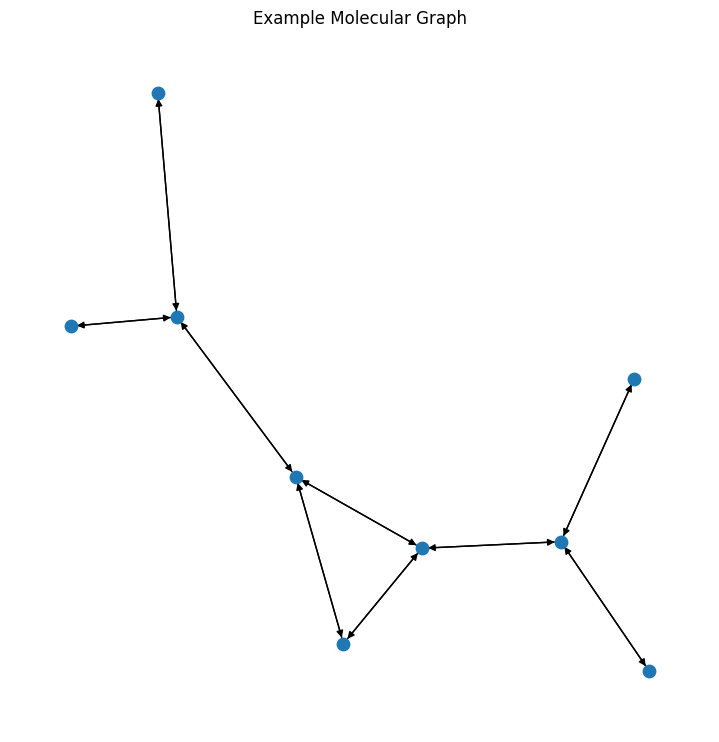

In [65]:
import networkx as nx
from torch_geometric.utils import to_networkx

graph = train_graphs[0]

G = to_networkx(graph)

plt.figure(figsize=(7,7))

nx.draw(
    G,
    node_size=80,
    with_labels=False
)

plt.title("Example Molecular Graph")

plt.savefig(
    "molecular_graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
print(train_graphs[0].y.shape)

torch.Size([1, 5])


In [67]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)

batch = next(iter(train_loader))
print(batch.y.shape)

torch.Size([32, 5])


In [68]:
probs = torch.sigmoid(out)
probs

tensor([[0.5354, 0.4912, 0.4429, 0.5308, 0.5217],
        [0.5401, 0.4930, 0.4363, 0.5262, 0.5273],
        [0.5350, 0.4910, 0.4425, 0.5301, 0.5225],
        [0.5353, 0.4911, 0.4409, 0.5279, 0.5248],
        [0.5381, 0.4902, 0.4419, 0.5300, 0.5184],
        [0.5383, 0.4931, 0.4386, 0.5279, 0.5264],
        [0.5382, 0.4897, 0.4423, 0.5297, 0.5195],
        [0.5349, 0.4918, 0.4418, 0.5292, 0.5242],
        [0.5337, 0.4915, 0.4419, 0.5294, 0.5237],
        [0.5377, 0.4908, 0.4417, 0.5305, 0.5189],
        [0.5332, 0.4916, 0.4431, 0.5305, 0.5239],
        [0.5385, 0.4885, 0.4434, 0.5286, 0.5195],
        [0.5377, 0.4910, 0.4416, 0.5307, 0.5185],
        [0.5385, 0.4873, 0.4430, 0.5272, 0.5214],
        [0.5357, 0.4915, 0.4409, 0.5279, 0.5246],
        [0.5378, 0.4908, 0.4409, 0.5287, 0.5211],
        [0.5372, 0.4910, 0.4404, 0.5271, 0.5239],
        [0.5354, 0.4920, 0.4410, 0.5279, 0.5255],
        [0.5369, 0.4914, 0.4394, 0.5269, 0.5231],
        [0.5384, 0.4892, 0.4419, 0.5283, 0.5196],


Model Optimization

In [69]:
import torch
import torch.nn as nn
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GNN().to(device)

pos_weight = []

for col in target_cols:
    pos = train[col].sum()
    neg = len(train) - pos
    pos_weight.append(neg / pos)

pos_weight = torch.tensor(pos_weight, dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=5e-5)

In [70]:
def train_one_epoch():
    model.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        # Forward pass
        out = model(batch.x, batch.edge_index, batch.batch)

        # Computing loss
        loss = criterion(out, batch.y.view(out.shape))

        loss.backward()

        # Updating weights
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [71]:
def evaluate():
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)

            out = model(batch.x, batch.edge_index, batch.batch)
            probs = torch.sigmoid(out)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(batch.y.view(-1, 5).cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    return all_probs, all_targets

In [73]:
from sklearn.metrics import matthews_corrcoef

train_losses = []
mcc_scores = []

for epoch in range(40):

    train_loss = train_one_epoch()

    val_probs, val_targets = evaluate()

    val_preds = (val_probs > 0.5).astype(int)

    mcc = matthews_corrcoef(
        val_targets.flatten(),
        val_preds.flatten()
    )

    train_losses.append(train_loss)
    mcc_scores.append(mcc)

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {train_loss:.4f} | "
        f"MCC: {mcc:.4f}"
    )

Epoch 1 | Loss: 1.1012 | MCC: 0.1185
Epoch 2 | Loss: 1.1014 | MCC: 0.1193
Epoch 3 | Loss: 1.1056 | MCC: 0.1916
Epoch 4 | Loss: 1.0979 | MCC: 0.3204
Epoch 5 | Loss: 1.0874 | MCC: 0.3059
Epoch 6 | Loss: 1.0745 | MCC: 0.3360
Epoch 7 | Loss: 1.0701 | MCC: 0.3655
Epoch 8 | Loss: 1.0503 | MCC: 0.3640
Epoch 9 | Loss: 1.0252 | MCC: 0.3732
Epoch 10 | Loss: 1.0060 | MCC: 0.3650
Epoch 11 | Loss: 0.9603 | MCC: 0.3648
Epoch 12 | Loss: 0.9291 | MCC: 0.3765
Epoch 13 | Loss: 0.9133 | MCC: 0.3605
Epoch 14 | Loss: 0.9002 | MCC: 0.3740
Epoch 15 | Loss: 0.8797 | MCC: 0.3738
Epoch 16 | Loss: 0.8739 | MCC: 0.3722
Epoch 17 | Loss: 0.8615 | MCC: 0.3791
Epoch 18 | Loss: 0.8579 | MCC: 0.3763
Epoch 19 | Loss: 0.8591 | MCC: 0.3762
Epoch 20 | Loss: 0.8458 | MCC: 0.3795
Epoch 21 | Loss: 0.8491 | MCC: 0.3829
Epoch 22 | Loss: 0.8450 | MCC: 0.3837
Epoch 23 | Loss: 0.8434 | MCC: 0.3893
Epoch 24 | Loss: 0.8462 | MCC: 0.3908
Epoch 25 | Loss: 0.8380 | MCC: 0.3901
Epoch 26 | Loss: 0.8531 | MCC: 0.3810
Epoch 27 | Loss: 0.84

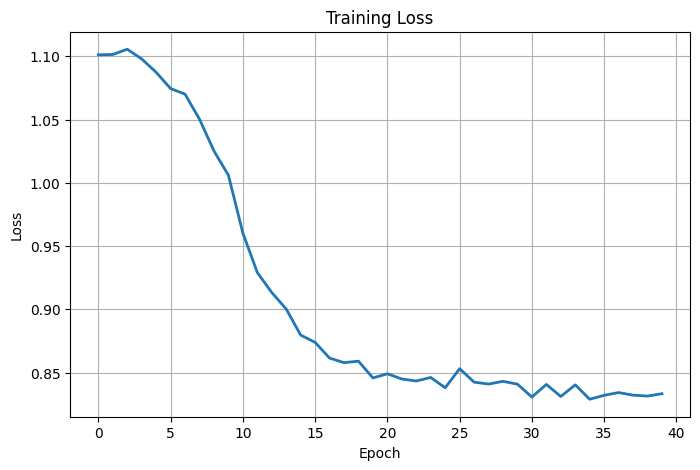

In [74]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    linewidth=2
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.savefig(
    "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
probs, targets = evaluate()

print(probs[:10])

[[0.07621697 0.15296112 0.14607649 0.2413091  0.19870989]
 [0.26705202 0.34685072 0.34542185 0.40312135 0.3665063 ]
 [0.7758665  0.73775285 0.73463607 0.66587013 0.70619136]
 [0.12361755 0.21624917 0.22043806 0.24146196 0.21994543]
 [0.6554752  0.64569664 0.6413559  0.5980661  0.62183726]
 [0.3414624  0.41005996 0.3993519  0.44798797 0.44020763]
 [0.01567353 0.05300588 0.04571957 0.10866591 0.08292171]
 [0.8202644  0.7724045  0.77005106 0.6935745  0.7357066 ]
 [0.6885375  0.67037654 0.6608796  0.6319739  0.66228116]
 [0.41079038 0.46592966 0.45768654 0.47226655 0.4764597 ]]


In [76]:
batch.y.view(batch.y.size(0), -1)

tensor([[0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [0., 1., 0., 1., 0.],
        [0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 1.],
        [0., 1., 0., 0., 1.],
        [0., 0., 0., 0., 0.],
        [1., 0., 1., 0., 1.],
        [1., 1., 0., 1., 1.]])

In [77]:
probs, targets = evaluate()

print("Probs shape:", probs.shape)
print("Targets shape:", targets.shape)

Probs shape: (462, 5)
Targets shape: (462, 5)


In [78]:
print(train_graphs[0].y)
print(train_graphs[0].y.shape)

tensor([[0., 0., 0., 0., 0.]])
torch.Size([1, 5])


MCC Evaluation

In [79]:
def compute_mcc(y_true, y_pred):
    return matthews_corrcoef(y_true, y_pred)

In [80]:
def find_best_threshold(y_true, probs):
    best_thresh = 0.5
    best_mcc = -1

    for t in np.linspace(0.0, 1.0, 101):
        preds = (probs >= t).astype(int)
        mcc = matthews_corrcoef(y_true, preds)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thresh = t

    return best_thresh, best_mcc

In [81]:
def tune_thresholds(all_probs, all_targets):
    thresholds = []
    mccs = []

    for i in range(5):
        probs = all_probs[:, i]
        targets = all_targets[:, i]

        t, mcc = find_best_threshold(targets, probs)

        thresholds.append(t)
        mccs.append(mcc)

        print(f"P{i+1}: Threshold={t:.2f}, MCC={mcc:.4f}")

    print("Final Score:", np.mean(mccs))

    return thresholds

In [82]:
probs, targets = evaluate()

import torch

if isinstance(probs, torch.Tensor):
    probs = probs.cpu().numpy()

if isinstance(targets, torch.Tensor):
    targets = targets.cpu().numpy()

thresholds = tune_thresholds(probs, targets)

P1: Threshold=0.81, MCC=0.5425
P2: Threshold=0.57, MCC=0.4317
P3: Threshold=0.55, MCC=0.3778
P4: Threshold=0.60, MCC=0.3401
P5: Threshold=0.48, MCC=0.4455
Final Score: 0.4275134317688033


In [95]:
test_preds = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)

        out = model(batch.x, batch.edge_index, batch.batch)

        probs = torch.sigmoid(out).cpu().detach().numpy()

        test_preds.append(probs)

test_preds = np.vstack(test_preds)

In [84]:
final_preds = np.zeros_like(test_preds)

for i in range(5):
    final_preds[:, i] = (test_preds[:, i] >= thresholds[i]).astype(int)

In [85]:
submission = pd.DataFrame()
submission[target_cols] = final_preds
submission.to_csv("submission.csv", index=False)

In [86]:
probs, targets = evaluate()

print(probs.shape)
print(targets.shape)

(462, 5)
(462, 5)


In [87]:
preds_05 = (probs >= 0.5).astype(int)

for i in range(5):
    print(matthews_corrcoef(targets[:, i], preds_05[:, i]))

0.5156488483192914
0.41318991983158077
0.3540782906951229
0.29483056930970236
0.420179844653372


FINAL SUBMISSION

In [88]:
import numpy as np

final_preds = np.zeros_like(test_preds)

for i in range(5):
    final_preds[:, i] = (test_preds[:, i] >= thresholds[i]).astype(int)

In [89]:
Submission = test[['M-ID']].copy()

In [90]:
Submission[target_cols] = final_preds

In [91]:
Submission.to_csv("submission.csv", index=False)

In [92]:
print(Submission.head())
print(Submission.shape)

      M-ID   P1   P2   P3   P4   P5
0  M414795  1.0  1.0  1.0  1.0  1.0
1  M284397  0.0  0.0  0.0  0.0  0.0
2  M472308  0.0  0.0  0.0  0.0  1.0
3  M836648  0.0  0.0  0.0  0.0  0.0
4  M794161  0.0  0.0  0.0  0.0  1.0
(578, 6)


In [93]:
from sklearn.metrics import matthews_corrcoef
import numpy as np

preds = (probs >= 0.5).astype(int)

mccs = []
for i in range(5):
    mcc = matthews_corrcoef(targets[:, i], preds[:, i])
    print(f"P{i+1} MCC:", mcc)
    mccs.append(mcc)

print("Final MCC:", np.mean(mccs))

P1 MCC: 0.5156488483192914
P2 MCC: 0.41318991983158077
P3 MCC: 0.3540782906951229
P4 MCC: 0.29483056930970236
P5 MCC: 0.420179844653372
Final MCC: 0.3995854945618139


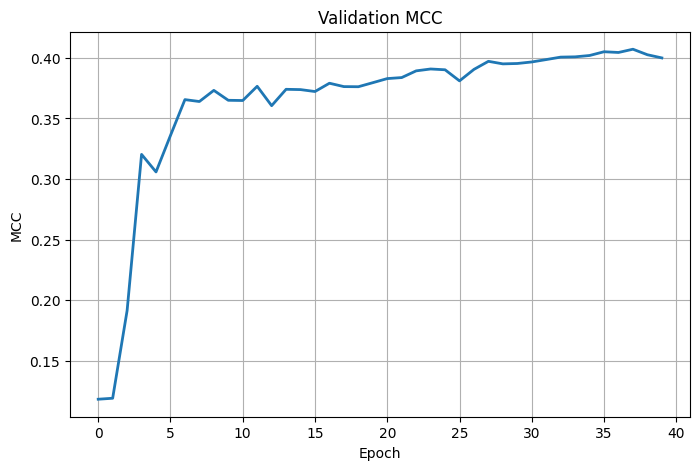

In [94]:
plt.figure(figsize=(8,5))

plt.plot(
    mcc_scores,
    linewidth=2
)

plt.title("Validation MCC")
plt.xlabel("Epoch")
plt.ylabel("MCC")
plt.grid()

plt.savefig(
    "mcc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Conclusion

This project explores the application of Graph Neural Networks (GNNs) for molecular property prediction by representing molecules as graph-structured data and learning relationships between atoms and chemical bonds.

Through this implementation, I experimented with molecular graph construction, deep learning on graph data, multi-label classification, and evaluation using Matthews Correlation Coefficient (MCC). The project provided valuable exposure to scientific machine learning workflows and the use of graph-based architectures for real-world prediction tasks.

Future work may include exploring Graph Attention Networks (GATs), Graph Transformers, advanced molecular feature engineering, and hyperparameter optimization to further improve predictive performance.

---
Developed for the OpenAImer Molecular Property Prediction Challenge.